In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import SilhouetteVisualizer

# GENERAMOS DATA

In [3]:
X,y,c = make_blobs(500,cluster_std=0.8,centers=4,n_features=2,return_centers=True)

In [4]:
df_blobs = pd.DataFrame(
    {
        'x1':X[:,0],
        'x2':X[:,1],
        'y':y
    }
)
df_blobs

,x1,x2,y
0,9.506445,-4.139889,0
1,-3.357157,2.451738,1
2,-7.591315,2.597027,2
3,8.126259,-5.214948,0
4,-4.588529,2.208730,1
...,...,...,...
495,9.586630,-5.995604,0
496,9.610326,-4.937457,0
497,8.024796,-4.349392,0
498,-10.113417,3.044248,2


In [5]:
df_centers = pd.DataFrame(
    {
        'x1':c[:,0],
        'x2':c[:,1]
    }
)
df_centers

,x1,x2
0,8.889121,-5.218849
1,-4.820751,2.625441
2,-7.869147,3.094503
3,-1.256098,0.305709


# GRAFICAMOS LOS DATOS

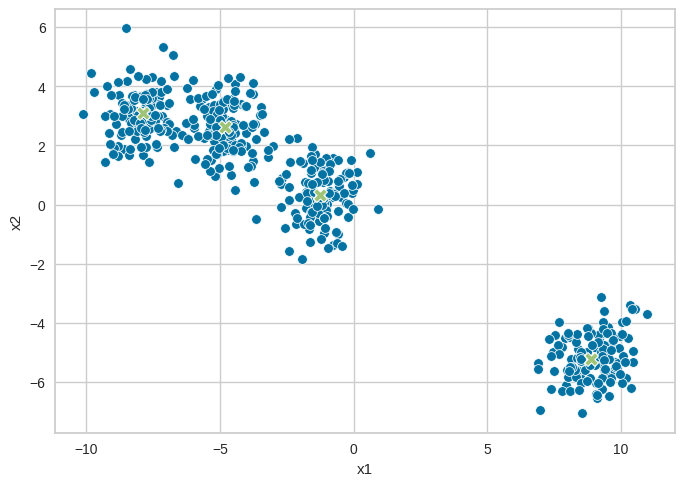

In [6]:
sns.scatterplot(data=df_blobs,x='x1',y='x2')
sns.scatterplot(data=df_centers,x='x1',y='x2',marker='X',s=100)
plt.show()

# APLICAMOS K-MEANS

In [7]:
kmeans = KMeans(n_clusters=4)
df_cluster = kmeans.fit_predict(X)
df_blobs['cluster'] = df_cluster
k_means_centers = kmeans.cluster_centers_
df_k_means_center = pd.DataFrame({
    'x1':k_means_centers[:,0],
    'x2':k_means_centers[:,1]
})
df_k_means_center

,x1,x2
0,8.937645,-5.171073
1,-4.801028,2.575965
2,-1.247167,0.317380
3,-7.963709,3.078291


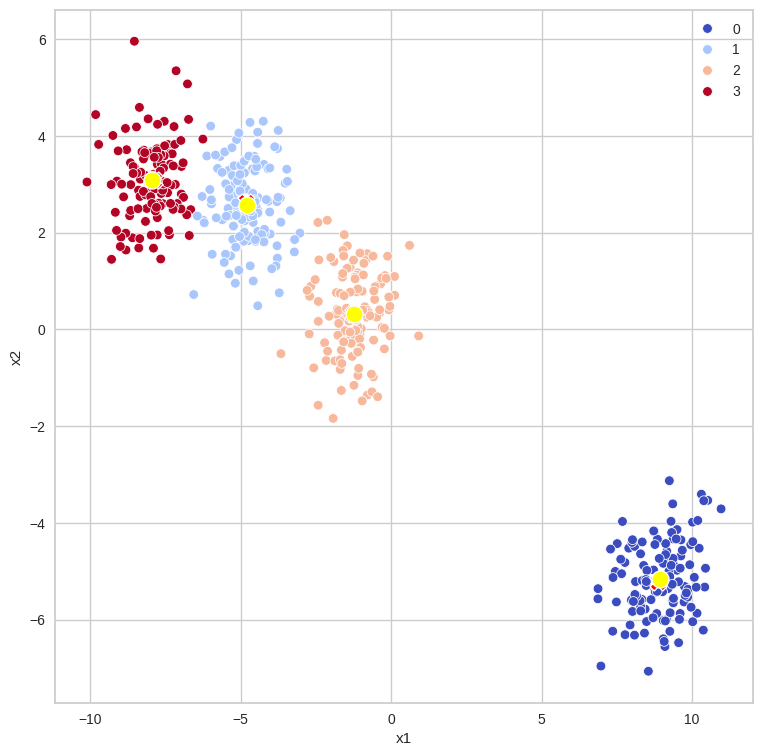

In [8]:
fig = plt.figure(figsize=(9,9))
sns.scatterplot(data=df_blobs,x='x1',y='x2',hue='cluster',palette='coolwarm')
sns.scatterplot(data=df_centers,  x='x1', y='x2', marker='X', s=150 , color='red')
sns.scatterplot(data=df_k_means_center,  x='x1', y='x2', marker='o', s=150 , color='yellow')
plt.show()

In [9]:
def vis_cluster(k):
    kmeans = KMeans(n_clusters=k)
    df_cluster = kmeans.fit_predict(X)
    df_blobs['cluster'] = df_cluster
    k_means_centers = kmeans.cluster_centers_
    df_k_means_center = pd.DataFrame(
        {
            'x1':k_means_centers[:,0],
            'x2':k_means_centers[:,1]

        }
    )
    fig = plt.figure(figsize=(9,9))
    sns.scatterplot(data=df_blobs,  x='x1', y='x2', hue= 'cluster', palette='coolwarm')
    sns.scatterplot(data=df_centers,  x='x1', y='x2', marker='X', s=150 , color='red')
    sns.scatterplot(data=df_k_means_center,  x='x1', y='x2', marker='o', s=150 , color='yellow')
    plt.show()

3


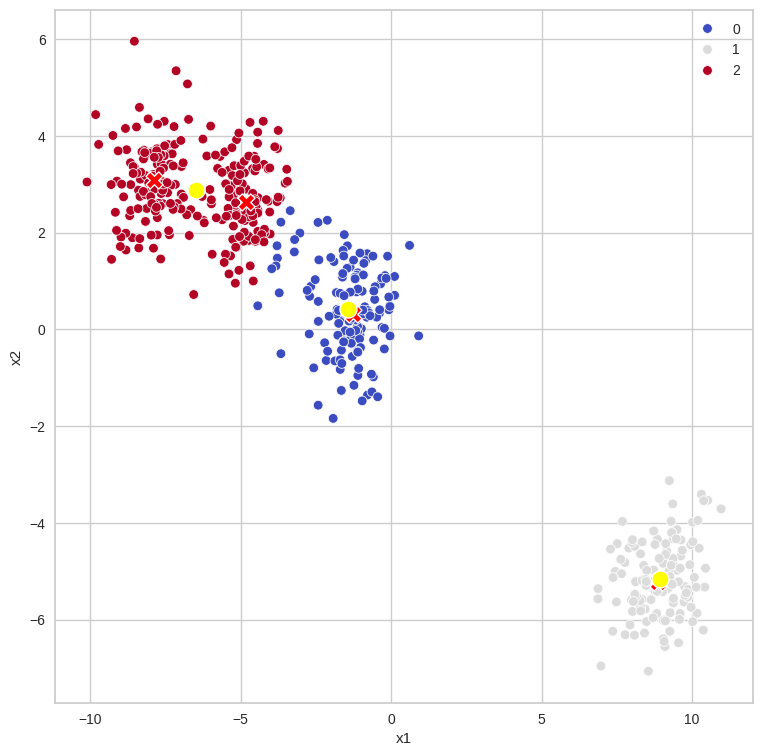

4


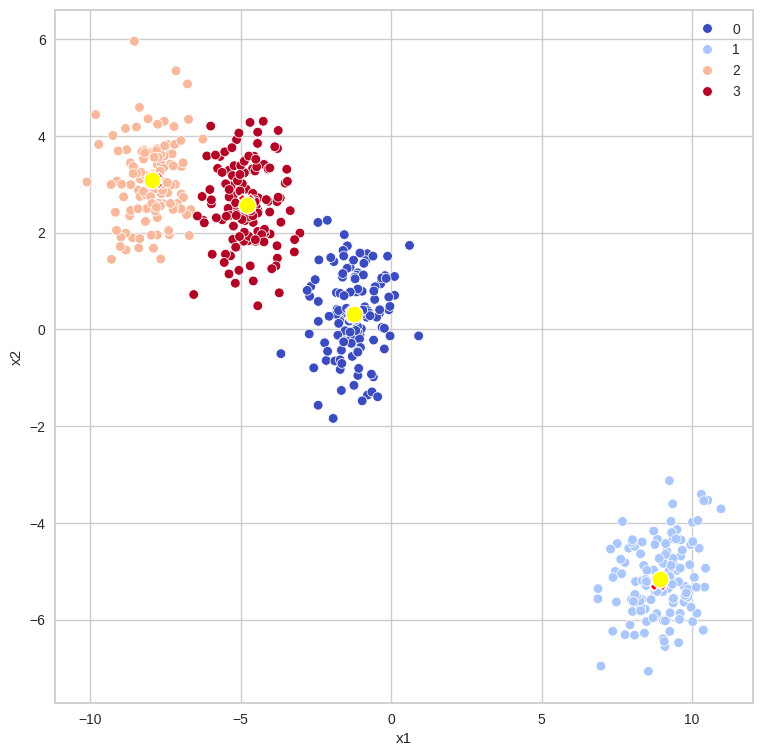

5


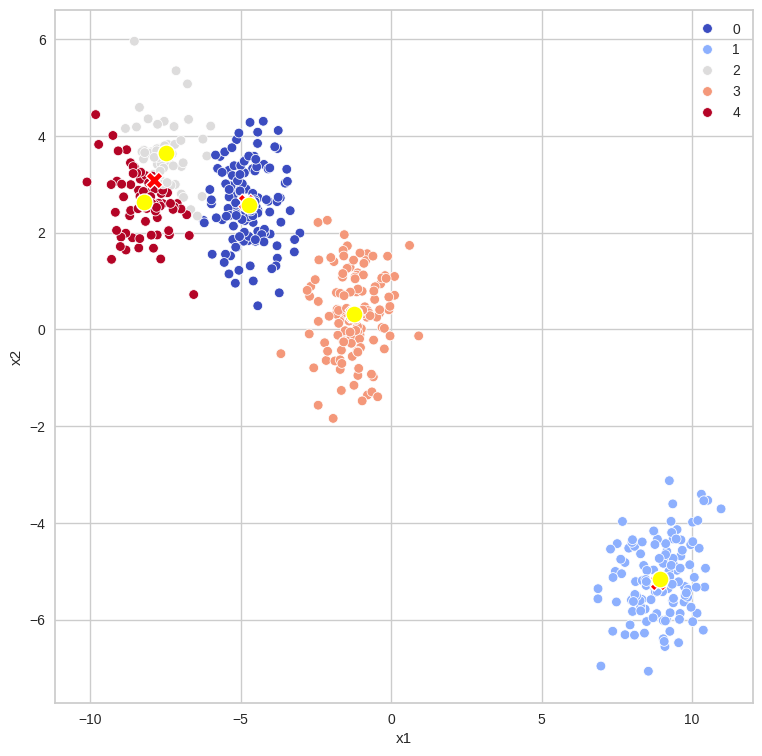

6


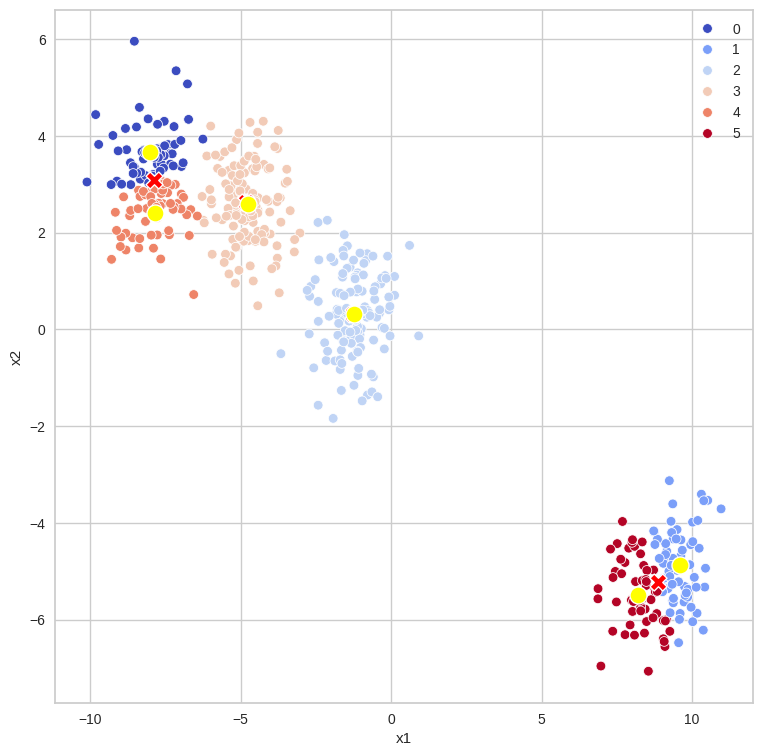

In [13]:
for _ in range(3,7):
    print(_)
    vis_cluster(_)

# ENCONTRAMOS EL VALOR IDEAL DE K

# COEFICIENTE DE SILUETA

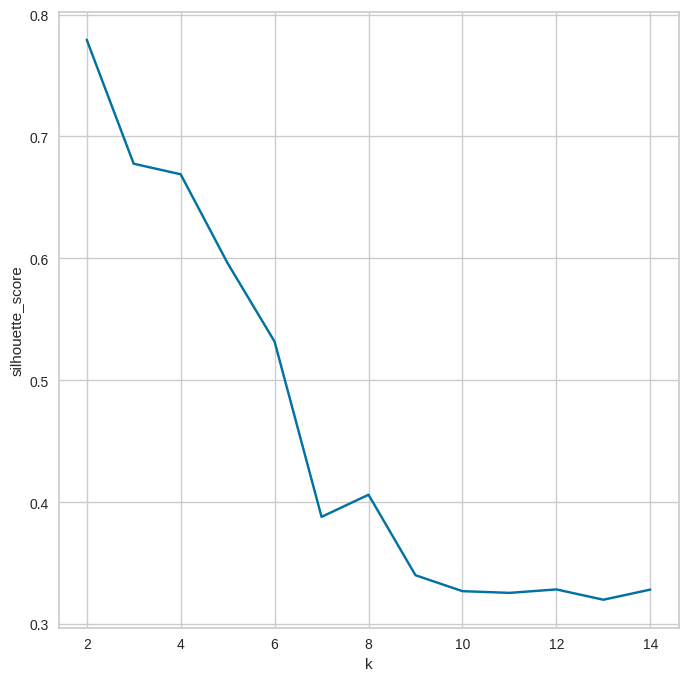

In [14]:
silhouette_scores = []
K = range(2,15)
for k in K:
  km = KMeans(n_clusters=k)
  km = km.fit(X)
  y = km.predict(X)
  silhouette_scores.append(silhouette_score(X,y))

plt.figure(figsize=(8,8))
plt.plot(K, silhouette_scores, 'bx-')
plt.xlabel('k')
plt.ylabel('silhouette_score')
plt.show()

SilhouetteVisualizer(ax=<Axes: >, colors='yellowbrick',
                     estimator=KMeans(n_clusters=4))

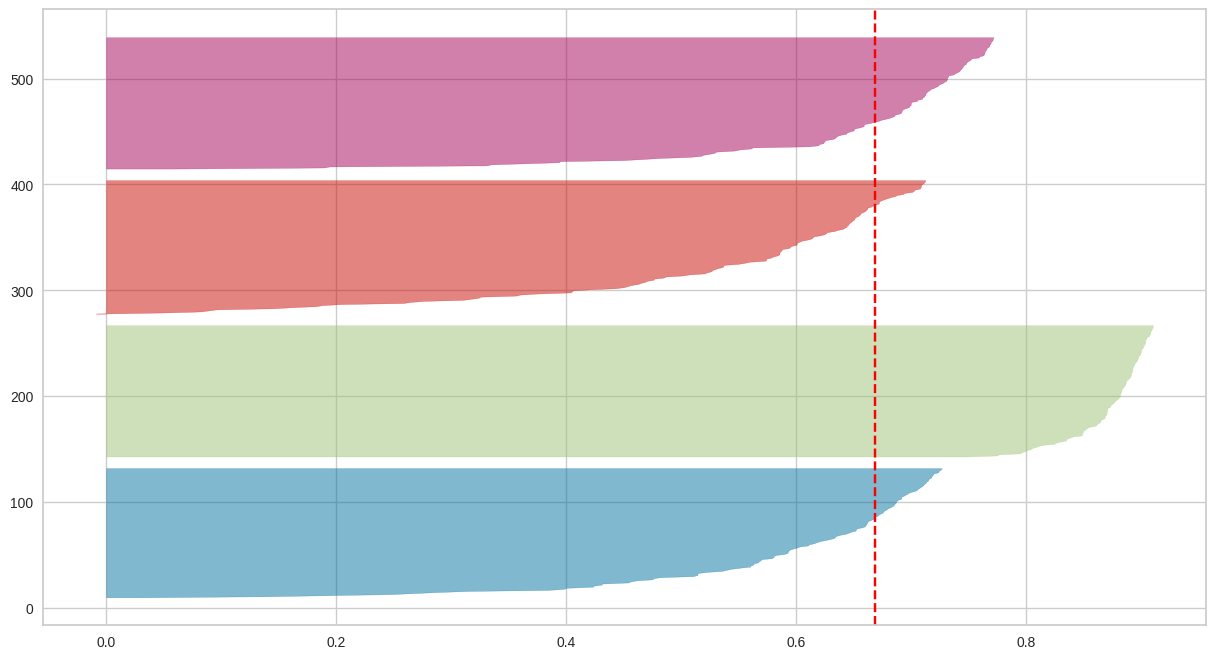

In [18]:
plt.figure(figsize=(15,8))
km = KMeans(n_clusters=4)
visualizer = SilhouetteVisualizer(km, colors='yellowbrick')
visualizer.fit(X)